# ℂ-VAE · Phase 8 — Day-1 Architecture Search

**Obiettivo:** ablation sistematica su attivazione, geometria latente, capacità, profondità, loss e dominio ℂ↔ℝ su backbone Swin V2 VAE, 80 epoche, FMA-small.

**Baseline di riferimento `cplx64x`** (Phase 7, non in questo CSV): ℂ, split CGeLU (*phase-destroying*), STFT_MSE+MRMEL, kl=1e-5, emb=64, 4s-PS4 [2,2,6,2], latent 128×8, improper — **FAD-MERT=8.37, CLAP=0.272, SI-SDR=-16.8dB**.

**Sorgente dati:** `runs.csv` (singolo file, tutte le run Swin). Run crashate (`State=failed`) filtrate automaticamente.

## Setup

In [16]:
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
Path('plots').mkdir(exist_ok=True)

def color_state(val):
    if val == 'finished': return 'color: green; font-weight: bold'
    if val == 'failed':   return 'color: red'
    return 'color: darkorange'

def color_domain(val):
    if val == 'ℂ': return 'color: #4C72B0; font-weight: bold'
    if val == 'ℝ': return 'color: #DD8452; font-weight: bold'
    return ''

DOMAIN_COLORS = {'ℂ': '#4C72B0', 'ℝ': '#DD8452'}
MODE_COLORS = {
    'improper':      '#4C72B0',
    'proper (C=0)':  '#55A868',
    'eigendec':      '#8172B3',
    'real_vae':      '#DD8452',
}
AXIS_COLORS = {
    'activation':     '#4C72B0',
    'epochs +40':     '#9FC5E8',
    'latent geometry':'#8172B3',
    'bottleneck':     '#55A868',
    'capacity ℂ':     '#17BECF',
    'domain ℂ→ℝ':     '#DD8452',
    'depth':          '#BCBD22',
    'loss config':    '#E377C2',
    'stages':         '#7F7F7F',
    'TEST':           '#CCCCCC',
}

## Load & Feature Engineering

In [17]:
# ── Carica CSV e filtra run crashate ─────────────────────────────────────────
df_raw = pd.read_csv('runs.csv')
df = df_raw[df_raw['State'] == 'finished'].copy().reset_index(drop=True)
print(f'Total rows: {len(df_raw)} | Finished: {len(df)} | Filtered out: {len(df_raw)-len(df)}')

# ── Rename ────────────────────────────────────────────────────────────────────
rename = {
    'models.model.swin.embed_dim':                          'embed_dim',
    'models.model.encoder.depths':                          'depths',
    'models.model.encoder.patch_size':                      'patch_size',
    'models.model.encoder.num_heads':                       'num_heads',
    'models.model.encoder.window_size':                     'window_size',
    'models.model.encoder.is_complex':                      'is_complex',
    'models.model.encoder.complex_activation':              'complex_activation',
    'models.model.bottleneck._target_':                     'bottleneck_target',
    'models.model.bottleneck.proper':                       'bottleneck_proper',
    'models.model.bottleneck.apply_spectral_parameterization': 'bottleneck_eigendec',
    'models.model.latent_channels':                         'latent_channels',
    'models.model.parameters_to_predict':                   'params_to_predict',
    'model_info.num_parameters_total':                      'n_params',
    'trainer.loss_config.bottleneck.weights.kl':            'kl_weight',
    'trainer.loss_config.spectral.weights.mrstft':          'mrstft_weight',
    'trainer.loss_config.mrmel.weights.mrmel':              'mrmel_weight',
    'trainer.loss_config.spectral.weights.stft_mse':        'stft_mse_weight',
    'trainer.optimizer.lr':                                 'lr',
    'trainer.trainer.epochs':                               'max_epochs',
    'trainer.trainer.clip_grad_norm':                       'clip_grad',
    'data.train_dataset.cac':                               'cac',
    'Runtime':                                              'runtime_s',
}
df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
df['runtime_hours'] = df['runtime_s'] / 3600
df['n_params_M']    = df['n_params'] / 1e6

# ── Derived: domain ───────────────────────────────────────────────────────────
df['domain'] = df['is_complex'].map({True: 'ℂ', False: 'ℝ'})

# ── Derived: n_stages, latent shape ──────────────────────────────────────────
def _parse_depths(d):
    if pd.isna(d): return None
    try: return ast.literal_eval(str(d))
    except: return None

def _latent_shape(row, H_in=1024, W_in=128):
    depths = _parse_depths(row.get('depths'))
    if depths is None: return '—'
    try:
        n = len(depths)
        ps = int(row['patch_size'])
        lc = int(row['latent_channels'])
        H = H_in // (ps * 2**(n-1))
        W = W_in  // (ps * 2**(n-1))
        return f'{lc}×{H}×{W}'
    except:
        return '—'

def _latent_seq(row, H_in=1024, W_in=128):
    depths = _parse_depths(row.get('depths'))
    if depths is None: return None
    try:
        n  = len(depths)
        ps = int(row['patch_size'])
        return (H_in // (ps * 2**(n-1))) * (W_in // (ps * 2**(n-1)))
    except:
        return None

df['n_stages']    = df['depths'].apply(lambda d: len(_parse_depths(d)) if _parse_depths(d) else None)
df['latent_shape']= df.apply(_latent_shape, axis=1)
df['latent_seq']  = df.apply(_latent_seq, axis=1)

# ── Derived: bottleneck mode ──────────────────────────────────────────────────
def _bottleneck_mode(row):
    if row.get('is_complex') == False or row.get('is_complex') is False:
        return 'real_vae'
    if row.get('bottleneck_eigendec') == True:
        return 'eigendec'
    if row.get('bottleneck_proper') == True:
        return 'proper (C=0)'
    return 'improper'

df['bottleneck_mode'] = df.apply(_bottleneck_mode, axis=1)

# ── Derived: loss label ───────────────────────────────────────────────────────
def _loss_label(row):
    if float(row.get('mrstft_weight', 0) or 0) > 0:
        return 'MRSTFT+MRMEL'
    if float(row.get('mrmel_weight', 0) or 0) > 0:
        return 'STFT_MSE+MRMEL'
    return 'STFT_MSE'

df['loss_label'] = df.apply(_loss_label, axis=1)

# ── Derived: run category + ablation metadata ─────────────────────────────────
#   (from HISTORY.md Day-1 ablation table)
ABLATION_META = {
    'r01_cplx_actfix':       ('activation',     'cplx64x (Phase 7)',     'ComplexGELU1d — phase-equivariant fix'),
    'r01_cplx_actfix_120ep': ('epochs +40',     'r01_cplx_actfix',       '+40 extra epochs (80→120)'),
    'r02_cplx_modrelu':      ('activation',     'r01_cplx_actfix',       'ModReLU — gate shape ablation'),
    'r03_cplx_ps8_compact':  ('latent geometry','r01_cplx_actfix',       'PS 4→8, latent 128×8→32×32 (×16 cheaper diffusion)'),
    'r04_cplx_emb96':        ('capacity ℂ',     'r01_cplx_actfix',       'embed_dim 64→96, ~110M (Swin V2-Tiny scale)'),
    'r05_real_emb136':       ('domain ℂ→ℝ',     'r04_cplx_emb96',        'ℝ iso-param di r04 · D_real≈96√2≈136 · ~110M'),
    'r06_cplx_deep':         ('depth',          'r01_cplx_actfix',       '[2,2,6,2]→[2,2,18,2] (+19M, Swin V2-S skeleton)'),
    'r07_cplx_mrstft':       ('loss config',    'r01_cplx_actfix',       'STFT_MSE→MRSTFT (winning SEANet loss config)'),
    'r08_real_mrstft':       ('domain ℂ→ℝ',     'r07_cplx_mrstft',       'ℝ iso-param di r07 · emb=92 · ~51M · MRSTFT'),
    'r09_cplx_ps8_proper':   ('bottleneck',     'r03_cplx_ps8_compact',  'improper→proper (C=0) su latent compatto'),
    'r10_cplx_ps8_eigendec': ('bottleneck',     'r03_cplx_ps8_compact',  'improper→eigendecomp su latent compatto'),
    'r11_real_baseline':     ('domain ℂ→ℝ',     'r01_cplx_actfix',       'ℝ iso-param di r01 · emb=92 · ~51M · STFT_MSE'),
    'r12_cplx_3stage':       ('stages',         'r01_cplx_actfix',       '4→3 stadi · PS 4→8 · emb 64→80 · iso-latent 128×8'),
}
TEST_NAMES = {'TEST_cplx_x64', 'TEST_real_x64', 'TEST_cplx_x64_2GPU', 'TEST_real_x64_2GPU'}

df['ablation_axis'] = df['Name'].map(lambda n: ABLATION_META.get(n, ('TEST',))[0])
df['vs_run']        = df['Name'].map(lambda n: ABLATION_META.get(n, ('', '—'))[1])
df['ablation_note'] = df['Name'].map(lambda n: ABLATION_META.get(n, ('', '', '—'))[2])
df['is_test']       = df['Name'].isin(TEST_NAMES)
df['color_domain']  = df['domain'].map(DOMAIN_COLORS)
df['color_mode']    = df['bottleneck_mode'].map(MODE_COLORS).fillna('#888888')
df['color_axis']    = df['ablation_axis'].map(AXIS_COLORS).fillna('#888888')

# ── Run order: r01→r12, then TEST ────────────────────────────────────────────
def _sort_key(name):
    import re
    m = re.match(r'r(\d+)', name)
    if m: return int(m.group(1))
    if name.startswith('TEST'): return 100
    return 99

df['_sort_key'] = df['Name'].apply(_sort_key)
df = df.sort_values('_sort_key').reset_index(drop=True)

# Separare Day-1 da TEST
df_day1 = df[~df['is_test']].copy()
df_test  = df[ df['is_test']].copy()

print(f'\nDay-1 runs: {len(df_day1)} | TEST runs: {len(df_test)}')
print(df_day1[['Name', 'domain', 'ablation_axis', 'epoch', 'State']].to_string(index=False))
print(df_test[['Name', 'domain', 'ablation_axis', 'epoch', 'State']].to_string(index=False))

Total rows: 23 | Finished: 17 | Filtered out: 6

Day-1 runs: 13 | TEST runs: 4
                 Name domain   ablation_axis  epoch    State
      r01_cplx_actfix      ℂ      activation   79.0 finished
r01_cplx_actfix_120ep      ℂ      epochs +40  119.0 finished
     r02_cplx_modrelu      ℂ      activation   79.0 finished
 r03_cplx_ps8_compact      ℂ latent geometry   79.0 finished
       r04_cplx_emb96      ℂ      capacity ℂ   79.0 finished
      r05_real_emb136      ℝ      domain ℂ→ℝ   79.0 finished
        r06_cplx_deep      ℂ           depth   79.0 finished
      r07_cplx_mrstft      ℂ     loss config   79.0 finished
      r08_real_mrstft      ℝ      domain ℂ→ℝ   79.0 finished
  r09_cplx_ps8_proper      ℂ      bottleneck   79.0 finished
r10_cplx_ps8_eigendec      ℂ      bottleneck   79.0 finished
    r11_real_baseline      ℝ      domain ℂ→ℝ   79.0 finished
      r12_cplx_3stage      ℂ          stages   79.0 finished
              Name domain ablation_axis  epoch    State
     TEST_c

## Configurazione Architetturale

In [18]:
arch_cols = [
    'Name', 'domain', 'ablation_axis',
    'embed_dim', 'depths', 'n_stages', 'patch_size', 'window_size',
    'complex_activation', 'bottleneck_mode', 'latent_channels', 'params_to_predict',
    'latent_shape', 'latent_seq',
    'loss_label', 'kl_weight',
    'n_params_M', 'max_epochs',
]
avail = [c for c in arch_cols if c in df.columns]

styled_arch = (
    df[avail]
    .style
    .applymap(color_domain, subset=['domain'])
    .background_gradient(subset=['n_params_M'], cmap='Blues')
    .background_gradient(subset=['embed_dim'],  cmap='Purples')
    .format({
        'n_params_M': '{:.1f}M',
        'kl_weight':  '{:.0e}',
        'latent_seq': '{:.0f}',
    }, na_rep='—')
    .set_caption('Day-1 + TEST — Configurazione Architetturale')
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '11px')]}])
)
display(styled_arch)

,Name,domain,ablation_axis,embed_dim,depths,n_stages,patch_size,window_size,complex_activation,bottleneck_mode,latent_channels,params_to_predict,latent_shape,latent_seq,loss_label,kl_weight,n_params_M,max_epochs
0,r01_cplx_actfix,ℂ,activation,64,"[2,2,6,2]",4,4,8,ComplexGELU1d,improper,8,3,8×32×4,128,STFT_MSE+MRMEL,1e-05,49.3M,80
1,r01_cplx_actfix_120ep,ℂ,epochs +40,64,"[2,2,6,2]",4,4,8,ComplexGELU1d,improper,8,3,8×32×4,128,STFT_MSE+MRMEL,1e-05,49.3M,120
2,r02_cplx_modrelu,ℂ,activation,64,"[2,2,6,2]",4,4,8,ModReLU,improper,8,3,8×32×4,128,STFT_MSE+MRMEL,1e-05,49.2M,80
3,r03_cplx_ps8_compact,ℂ,latent geometry,64,"[2,2,6,2]",4,8,8,ComplexGELU1d,improper,32,3,32×16×2,32,STFT_MSE+MRMEL,1e-05,49.4M,80
4,r04_cplx_emb96,ℂ,capacity ℂ,96,"[2,2,6,2]",4,4,8,ComplexGELU1d,improper,8,3,8×32×4,128,STFT_MSE+MRMEL,1e-05,110.3M,80
5,r05_real_emb136,ℝ,domain ℂ→ℝ,136,"[2,2,6,2]",4,4,8,—,real_vae,16,2,16×32×4,128,STFT_MSE+MRMEL,1e-05,110.5M,80
6,r06_cplx_deep,ℂ,depth,64,"[2,2,18,2]",4,4,8,ComplexGELU1d,improper,8,3,8×32×4,128,STFT_MSE+MRMEL,1e-05,87.5M,80
7,r07_cplx_mrstft,ℂ,loss config,64,"[2,2,6,2]",4,4,8,ComplexGELU1d,improper,8,3,8×32×4,128,MRSTFT+MRMEL,1e-05,49.3M,80
8,r08_real_mrstft,ℝ,domain ℂ→ℝ,92,"[2,2,6,2]",4,4,8,—,real_vae,16,2,16×32×4,128,MRSTFT+MRMEL,1e-05,50.8M,80
9,r09_cplx_ps8_proper,ℂ,bottleneck,64,"[2,2,6,2]",4,8,8,ComplexGELU1d,proper (C=0),32,2,32×16×2,32,STFT_MSE+MRMEL,1e-05,49.3M,80


## Metriche di Validazione

In [19]:
metric_cols = [
    'Name', 'domain', 'ablation_axis', 'ablation_note',
    'epoch', 'val/stft', 'val/mel', 'val/sisdr', 'val/kl',
    'train/latent_std', 'train/kl_weight', 'n_params_M', 'runtime_hours',
]
avail = [c for c in metric_cols if c in df.columns]

METRIC_DIR = {'val/stft': True, 'val/mel': True, 'val/sisdr': False, 'val/kl': True}

styled_metrics = (
    df[avail]
    .style
    .applymap(color_domain, subset=['domain'])
    .background_gradient(subset=['val/stft'],  cmap='RdYlGn_r')
    .background_gradient(subset=['val/mel'],   cmap='RdYlGn_r')
    .background_gradient(subset=['val/sisdr'], cmap='RdYlGn')
    .background_gradient(subset=['val/kl'],    cmap='RdYlGn_r')
    .format({
        'val/stft':         '{:.4f}',
        'val/mel':          '{:.4f}',
        'val/sisdr':        '{:.2f}',
        'val/kl':           '{:.1f}',
        'train/latent_std': '{:.3f}',
        'train/kl_weight':  '{:.0e}',
        'n_params_M':       '{:.1f}M',
        'runtime_hours':    '{:.1f}h',
    }, na_rep='—')
    .set_caption('Metriche finali (ultima epoca loggata) — verde = meglio per metrica')
)
display(styled_metrics)

,Name,domain,ablation_axis,ablation_note,epoch,val/stft,val/mel,val/sisdr,val/kl,train/latent_std,train/kl_weight,n_params_M,runtime_hours
0,r01_cplx_actfix,ℂ,activation,ComplexGELU1d — phase-equivariant fix,79.000000,2.0916,2.1647,-37.38,78.3,1.470,1e-05,49.3M,42.7h
1,r01_cplx_actfix_120ep,ℂ,epochs +40,+40 extra epochs (80→120),119.000000,2.0911,2.1542,-37.23,75.0,1.278,1e-05,49.3M,40.0h
2,r02_cplx_modrelu,ℂ,activation,ModReLU — gate shape ablation,79.000000,2.1037,2.1577,-37.54,78.0,1.419,1e-05,49.2M,42.7h
3,r03_cplx_ps8_compact,ℂ,latent geometry,"PS 4→8, latent 128×8→32×32 (×16 cheaper diffusion)",79.000000,2.1780,2.2244,-34.38,220.4,0.874,1e-05,49.4M,42.9h
4,r04_cplx_emb96,ℂ,capacity ℂ,"embed_dim 64→96, ~110M (Swin V2-Tiny scale)",79.000000,2.0985,2.1673,-37.03,81.4,1.518,1e-05,110.3M,42.6h
5,r05_real_emb136,ℝ,domain ℂ→ℝ,ℝ iso-param di r04 · D_real≈96√2≈136 · ~110M,79.000000,2.1242,2.1626,-37.12,154.4,1.686,1e-05,110.5M,36.3h
6,r06_cplx_deep,ℂ,depth,"[2,2,6,2]→[2,2,18,2] (+19M, Swin V2-S skeleton)",79.000000,2.1126,2.1670,-37.25,77.3,1.375,1e-05,87.5M,42.6h
7,r07_cplx_mrstft,ℂ,loss config,STFT_MSE→MRSTFT (winning SEANet loss config),79.000000,2.1069,2.2644,-38.58,83.3,1.748,1e-05,49.3M,42.8h
8,r08_real_mrstft,ℝ,domain ℂ→ℝ,ℝ iso-param di r07 · emb=92 · ~51M · MRSTFT,79.000000,2.1302,2.2867,-39.33,186.3,2.178,1e-05,50.8M,36.3h
9,r09_cplx_ps8_proper,ℂ,bottleneck,improper→proper (C=0) su latent compatto,79.000000,2.1717,2.2213,-37.74,226.8,0.865,1e-05,49.3M,42.4h


In [20]:
# ── Confronto iso-param ℂ vs ℝ ────────────────────────────────────────────────
iso_pairs = [
    ('r01_cplx_actfix',  'r11_real_baseline', '~49M vs ~51M  ·  STFT_MSE+MRMEL'),
    ('r07_cplx_mrstft',  'r08_real_mrstft',   '~49M vs ~51M  ·  MRSTFT+MRMEL'),
    ('r04_cplx_emb96',   'r05_real_emb136',   '~110M vs ~111M · STFT_MSE+MRMEL'),
]

metric_show = ['val/stft', 'val/mel', 'val/sisdr', 'val/kl', 'n_params_M']

print(f"{'Pair':<50}  {'metric':<15}  {'ℂ value':>10}  {'ℝ value':>10}  {'delta (ℂ-ℝ)':>12}")
print('-' * 105)
for cplx_name, real_name, note in iso_pairs:
    row_c = df[df['Name'] == cplx_name]
    row_r = df[df['Name'] == real_name]
    if row_c.empty or row_r.empty:
        print(f'{note:<50}  (run not found)')
        continue
    print(f'  {note}')
    for m in metric_show:
        if m not in df.columns: continue
        vc = row_c[m].values[0]
        vr = row_r[m].values[0]
        if pd.isna(vc) or pd.isna(vr): continue
        fmt = '{:.4f}' if 'stft' in m or 'mel' in m else '{:.2f}' if 'sisdr' in m or 'kl' in m else '{:.1f}M'
        delta = vc - vr
        sign  = '▲' if delta > 0 else '▼'
        print(f'  {"":<48}  {m:<15}  {fmt.format(vc):>10}  {fmt.format(vr):>10}  {sign}{abs(delta):>10.4f}')
    print()

Pair                                                metric              ℂ value     ℝ value   delta (ℂ-ℝ)
---------------------------------------------------------------------------------------------------------
  ~49M vs ~51M  ·  STFT_MSE+MRMEL
                                                    val/stft             2.0916      2.1279  ▼    0.0363
                                                    val/mel              2.1647      2.1654  ▼    0.0007
                                                    val/sisdr            -37.38      -37.85  ▲    0.4703
                                                    val/kl                78.26      152.07  ▼   73.8059
                                                    n_params_M            49.3M       50.8M  ▼    1.5081

  ~49M vs ~51M  ·  MRSTFT+MRMEL
                                                    val/stft             2.1069      2.1302  ▼    0.0232
                                                    val/mel              2.2644      2.2867

## Trade-off KL / Ricostruzione

In [21]:
sub = df[df['val/kl'].notna() & df['val/stft'].notna()].copy()

fig = px.scatter(
    sub,
    x='val/kl', y='val/stft',
    color='domain',
    symbol='bottleneck_mode',
    size='n_params_M', size_max=30,
    hover_name='Name',
    hover_data={
        'ablation_note': True,
        'epoch': True,
        'val/mel': ':.4f',
        'val/sisdr': ':.2f',
        'train/latent_std': ':.3f',
        'n_params_M': ':.1f',
        'loss_label': True,
    },
    text='Name',
    color_discrete_map=DOMAIN_COLORS,
    log_x=True,
    title='Trade-off: KL Divergence vs STFT Loss (log scale)',
    labels={'val/kl': 'Val KL (log) ↓', 'val/stft': 'Val STFT ↓'},
    template='plotly_white', width=1000, height=560,
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.show()

# ── SI-SDR vs STFT ────────────────────────────────────────────────────────────
sub2 = df[df['val/stft'].notna() & df['val/sisdr'].notna()].copy()
fig2 = px.scatter(
    sub2,
    x='val/stft', y='val/sisdr',
    color='domain',
    symbol='bottleneck_mode',
    size='n_params_M', size_max=30,
    hover_name='Name',
    hover_data={
        'ablation_note': True,
        'epoch': True,
        'val/kl': ':.1f',
        'loss_label': True,
        'n_params_M': ':.1f',
    },
    text='Name',
    color_discrete_map=DOMAIN_COLORS,
    title='STFT Loss vs SI-SDR (↙ meglio)',
    labels={'val/stft': 'Val STFT ↓', 'val/sisdr': 'Val SI-SDR ↑'},
    template='plotly_white', width=1000, height=560,
)
fig2.update_traces(textposition='top center', textfont_size=9)
fig2.show()

## Analisi Latent Statistics

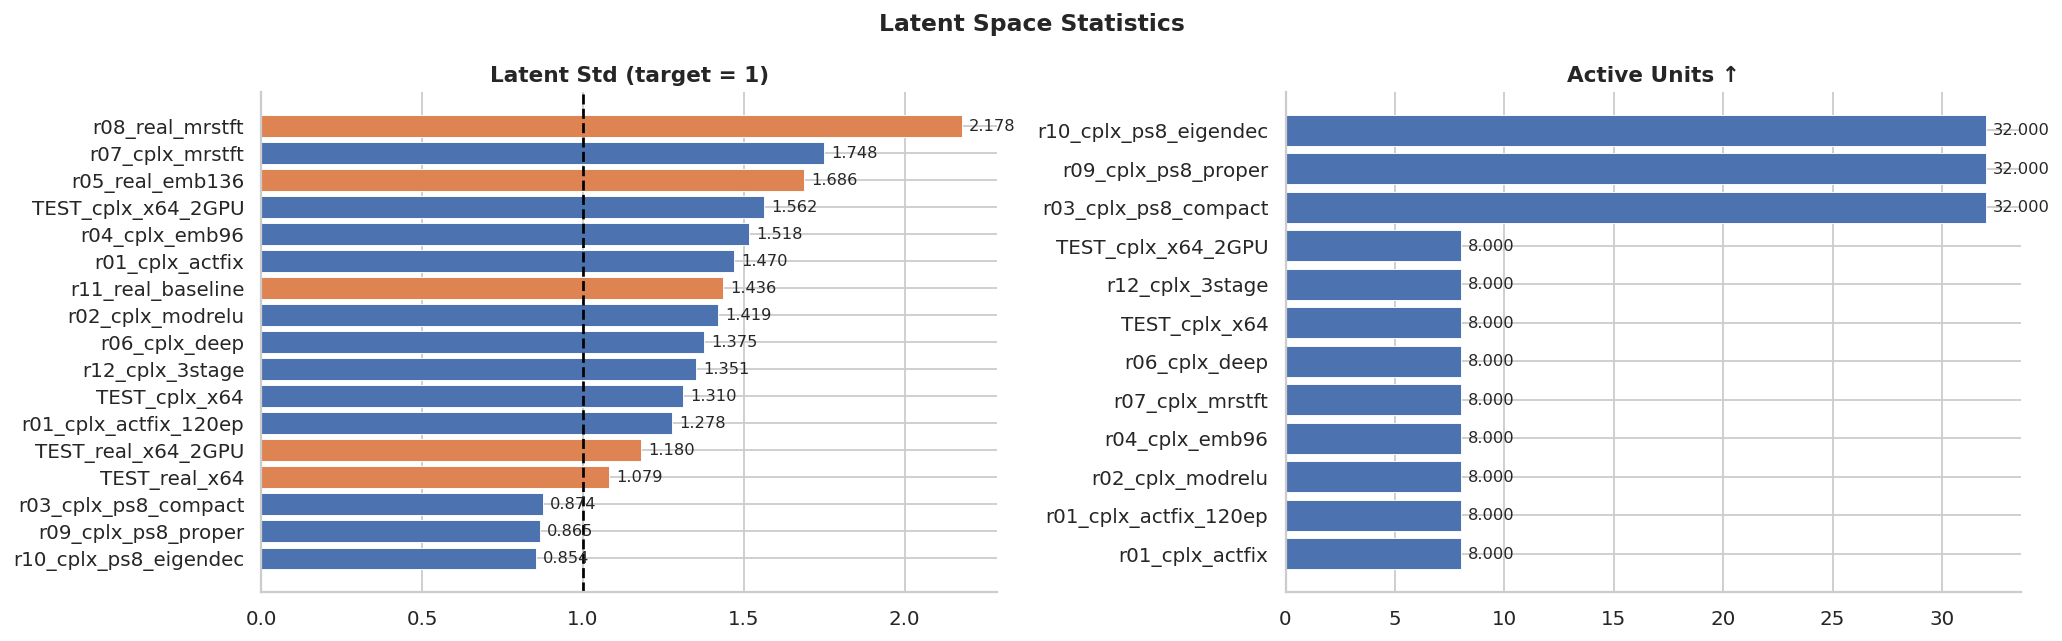

In [22]:
if 'train/latent_std' in df.columns and 'train/active_units' in df.columns:
    # latent_std + active_units per run
    sub = df[df['train/latent_std'].notna()].copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    for ax, metric, label, target in [
        (ax1, 'train/latent_std',    'Latent Std (target = 1)', 1.0),
        (ax2, 'train/active_units',  'Active Units ↑', None),
    ]:
        if metric not in sub.columns:
            ax.set_visible(False)
            continue
        s = sub[sub[metric].notna()].sort_values(metric)
        bars = ax.barh(s['Name'], s[metric], color=s['color_domain'],
                       edgecolor='white', lw=0.5)
        ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
        if target is not None:
            ax.axvline(target, color='black', linestyle='--', lw=1.5)
        ax.set_title(label, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('Latent Space Statistics', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/latent_stats.png', bbox_inches='tight')
    plt.show()
elif 'train/latent_std' in df.columns:
    sub = df[df['train/latent_std'].notna()].sort_values('train/latent_std')
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(sub['Name'], sub['train/latent_std'],
                   color=sub['color_domain'], edgecolor='white', lw=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.axvline(1.0, color='black', linestyle='--', lw=1.5, label='σ=1 (target)')
    ax.legend()
    ax.set_title('Latent Std (train) — target = 1.0', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('plots/latent_std.png', bbox_inches='tight')
    plt.show()
else:
    print('Nessuna metrica latent disponibile.')

## Ranking Day-1 (solo run r01–r12)

In [23]:
# Candidati al ruolo di 'winner' per il Day-N KL sweep
# Criteri: migliore val/stft o val/mel (proxy per FAD fino a eval completo)

METRICS_RANK = ['val/stft', 'val/mel', 'val/sisdr']

for m in METRICS_RANK:
    if m not in df_day1.columns: continue
    lower = m != 'val/sisdr'
    ranked = (
        df_day1[df_day1[m].notna()]
        .sort_values(m, ascending=lower)[['Name', 'domain', 'ablation_note', m]]
        .reset_index(drop=True)
    )
    ranked.index += 1
    print(f'\n--- Ranking per {m} ({"↓" if lower else "↑"} meglio) ---')
    print(ranked.to_string())

print('\n⭐ Top-3 candidati winner (per val/stft):')
top3 = df_day1.sort_values('val/stft').head(3)[['Name', 'domain', 'ablation_note', 'val/stft', 'val/mel', 'n_params_M']]
print(top3.to_string(index=False))


--- Ranking per val/stft (↓ meglio) ---
                     Name domain                                       ablation_note  val/stft
1   r01_cplx_actfix_120ep      ℂ                           +40 extra epochs (80→120)  2.091062
2         r01_cplx_actfix      ℂ               ComplexGELU1d — phase-equivariant fix  2.091581
3          r04_cplx_emb96      ℂ         embed_dim 64→96, ~110M (Swin V2-Tiny scale)  2.098456
4        r02_cplx_modrelu      ℂ                       ModReLU — gate shape ablation  2.103679
5         r07_cplx_mrstft      ℂ        STFT_MSE→MRSTFT (winning SEANet loss config)  2.106915
6           r06_cplx_deep      ℂ     [2,2,6,2]→[2,2,18,2] (+19M, Swin V2-S skeleton)  2.112593
7         r05_real_emb136      ℝ        ℝ iso-param di r04 · D_real≈96√2≈136 · ~110M  2.124191
8       r11_real_baseline      ℝ       ℝ iso-param di r01 · emb=92 · ~51M · STFT_MSE  2.127931
9         r08_real_mrstft      ℝ         ℝ iso-param di r07 · emb=92 · ~51M · MRSTFT  2.130154
10       

## Full Eval — Phase 7 Historical Reference

Checkpoint evaluation su FMA-small (800 files). Contiene SEANet + Swin Phase 7 (non Day-1).  
Fonte: `runs/eval_sweep/summary.csv`.

In [24]:
import pickle, zipfile, io as _io

def _epoch_from_ckpt(path):
    try:
        with zipfile.ZipFile(path) as zf:
            raw = zf.read(next(n for n in zf.namelist() if n.endswith('data.pkl')))
        class _Skip(pickle.Unpickler):
            def persistent_load(self, pid): return None
            def find_class(self, m, n):
                return (lambda *a, **kw: None) if m.startswith('torch') else super().find_class(m, n)
        return _Skip(_io.BytesIO(raw)).load().get('epoch')
    except Exception:
        return None

PROJECT_ROOT = Path('/leonardo/home/userexternal/fbrigant/work/C-VAE')
EVAL_ROOT    = PROJECT_ROOT / 'runs' / 'eval_sweep'

df_eval = pd.read_csv(EVAL_ROOT / 'summary.csv').rename(columns={
    'si_sdr_mean':           'si_sdr',
    'stft_loss_mean':        'stft_loss',
    'clap_music_mean':       'clap_music',
    'clap_audio_mean':       'clap_audio',
    'cdpam_mean':            'cdpam',
    'fad_fadtk_mert':        'fad_mert',
    'fad_gudgud_clap-audio': 'fad_gudgud',
})

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_ROOT / p

df_eval['epoch'] = df_eval['checkpoint_path'].apply(
    lambda p: _epoch_from_ckpt(_resolve(p)) if pd.notna(p) else None
)

# Aggiungi etichetta architettura
CKPT_ARCH = {
    'TESTcplx':                    'Swin ℂ · 50ep · 1GPU',
    'TESTcplx2GPU':                'Swin ℂ · 50ep · 2GPU',
    'TESTreal':                    'Swin ℝ · 50ep · 1GPU',
    'TESTreal2GPU':                'Swin ℝ · 50ep · 2GPU',
    'real64x':                     'Swin ℝ · 79ep · emb=64 · STFT_MSE',
    'cplx64x':                     'Swin ℂ · 79ep · emb=64 · STFT_MSE+MRMEL · CGeLU',
    'cplx_kl5e-4_ep29':            'SEANet ℂ · 29ep · kl=5e-4',
    'cplx_kl5e-5_ep29':            'SEANet ℂ · 29ep · kl=5e-5',
    'cplx_kl1e-3_ep29':            'SEANet ℂ · 29ep · kl=1e-3',
    'cplx_kl1e-4_ep29':            'SEANet ℂ · 29ep · kl=1e-4',
    'cplx_mrstft_mrmel_kl1e-4_ep79': 'SEANet ℂ · 79ep · MRSTFT+MRMEL · kl=1e-4 ← BEST',
    'cplx_mrstft_mrmel_kl5e-5_ep79': 'SEANet ℂ · 79ep · MRSTFT+MRMEL · kl=5e-5',
    'swin_real_ae_ep79':            'Swin ℝ AE · 79ep (no bottleneck)',
}
df_eval['arch_label'] = df_eval['checkpoint'].map(CKPT_ARCH).fillna('—')

cols = ['checkpoint', 'arch_label', 'epoch', 'stft_loss', 'si_sdr',
        'cdpam', 'clap_music', 'clap_audio', 'fad_mert', 'fad_gudgud']
df_eval = df_eval[[c for c in cols if c in df_eval.columns]]

print(f'Loaded {len(df_eval)} Phase-7 checkpoints')
display(df_eval)

Loaded 13 Phase-7 checkpoints


,checkpoint,arch_label,epoch,stft_loss,si_sdr,cdpam,clap_music,clap_audio,fad_mert,fad_gudgud
0,TESTcplx,Swin ℂ · 50ep · 1GPU,49.0,3.308639,-34.240263,0.000258,0.088852,0.033473,17.111077,1.690038
1,TESTcplx2GPU,Swin ℂ · 50ep · 2GPU,49.0,3.324196,-34.180657,0.000259,0.090534,0.038372,15.846302,1.677993
2,TESTreal,Swin ℝ · 50ep · 1GPU,49.0,3.313086,-30.630982,0.000480,0.182120,0.141618,13.556152,1.298529
3,TESTreal2GPU,Swin ℝ · 50ep · 2GPU,49.0,3.088669,-31.054386,0.000446,0.165947,0.130185,14.268343,1.331974
4,real64x,Swin ℝ · 79ep · emb=64 · STFT_MSE,NaN,3.255821,-30.717351,0.000427,0.186755,0.140472,14.371552,1.286194
5,cplx64x,Swin ℂ · 79ep · emb=64 · STFT_MSE+MRMEL · CGeLU,NaN,3.026768,-16.821177,0.000314,0.272090,0.229750,8.367673,1.038830
6,cplx_mrstft_mrmel_kl1e-4_ep79,SEANet ℂ · 79ep · MRSTFT+MRMEL · kl=1e-4 ← BEST,NaN,2.172460,0.696104,0.000099,0.475368,0.479137,1.500701,0.662178
7,cplx_kl5e-4_ep29,SEANet ℂ · 29ep · kl=5e-4,29.0,2.736962,-1.638800,0.000099,0.337927,0.308079,4.186597,0.934804
8,cplx_kl5e-5_ep29,SEANet ℂ · 29ep · kl=5e-5,29.0,2.515378,-0.824169,0.000077,0.416903,0.402687,2.297127,0.785933
9,cplx_kl1e-3_ep29,SEANet ℂ · 29ep · kl=1e-3,NaN,3.017443,-3.344019,0.000135,0.270927,0.229565,7.202637,1.063153


In [25]:
METRIC_FMT = {
    'stft_loss':  ('{:.4f}', True),
    'si_sdr':     ('{:.2f}', False),
    'cdpam':      ('{:.5f}', True),
    'clap_music': ('{:.4f}', False),
    'clap_audio': ('{:.4f}', False),
    'fad_mert':   ('{:.3f}', True),
    'fad_gudgud': ('{:.3f}', True),
}

num_cols  = [c for c in METRIC_FMT if c in df_eval.columns]
fmt_dict  = {c: METRIC_FMT[c][0] for c in num_cols}

styled_eval = (
    df_eval[['checkpoint', 'arch_label', 'epoch'] + num_cols]
    .sort_values('fad_mert' if 'fad_mert' in df_eval.columns else 'stft_loss')
    .style
    .format(fmt_dict, na_rep='—')
    .set_caption('Phase 7 Full Eval (FMA-small 800 files) — verde = meglio')
)
for col in num_cols:
    lower_better = METRIC_FMT[col][1]
    cmap = 'RdYlGn_r' if lower_better else 'RdYlGn'
    styled_eval = styled_eval.background_gradient(subset=[col], cmap=cmap)

display(styled_eval)

,checkpoint,arch_label,epoch,stft_loss,si_sdr,cdpam,clap_music,clap_audio,fad_mert,fad_gudgud
6,cplx_mrstft_mrmel_kl1e-4_ep79,SEANet ℂ · 79ep · MRSTFT+MRMEL · kl=1e-4 ← BEST,—,2.1725,0.70,0.00010,0.4754,0.4791,1.501,0.662
12,cplx_mrstft_mrmel_kl5e-5_ep79,SEANet ℂ · 79ep · MRSTFT+MRMEL · kl=5e-5,—,2.3612,-0.86,0.00013,0.4668,0.4660,1.842,0.684
8,cplx_kl5e-5_ep29,SEANet ℂ · 29ep · kl=5e-5,29.000000,2.5154,-0.82,0.00008,0.4169,0.4027,2.297,0.786
10,cplx_kl1e-4_ep29,SEANet ℂ · 29ep · kl=1e-4,—,2.5744,-0.74,0.00009,0.4163,0.4030,2.406,0.787
7,cplx_kl5e-4_ep29,SEANet ℂ · 29ep · kl=5e-4,29.000000,2.7370,-1.64,0.00010,0.3379,0.3081,4.187,0.935
9,cplx_kl1e-3_ep29,SEANet ℂ · 29ep · kl=1e-3,—,3.0174,-3.34,0.00013,0.2709,0.2296,7.203,1.063
5,cplx64x,Swin ℂ · 79ep · emb=64 · STFT_MSE+MRMEL · CGeLU,—,3.0268,-16.82,0.00031,0.2721,0.2297,8.368,1.039
2,TESTreal,Swin ℝ · 50ep · 1GPU,49.000000,3.3131,-30.63,0.00048,0.1821,0.1416,13.556,1.299
3,TESTreal2GPU,Swin ℝ · 50ep · 2GPU,49.000000,3.0887,-31.05,0.00045,0.1659,0.1302,14.268,1.332
4,real64x,Swin ℝ · 79ep · emb=64 · STFT_MSE,—,3.2558,-30.72,0.00043,0.1868,0.1405,14.372,1.286


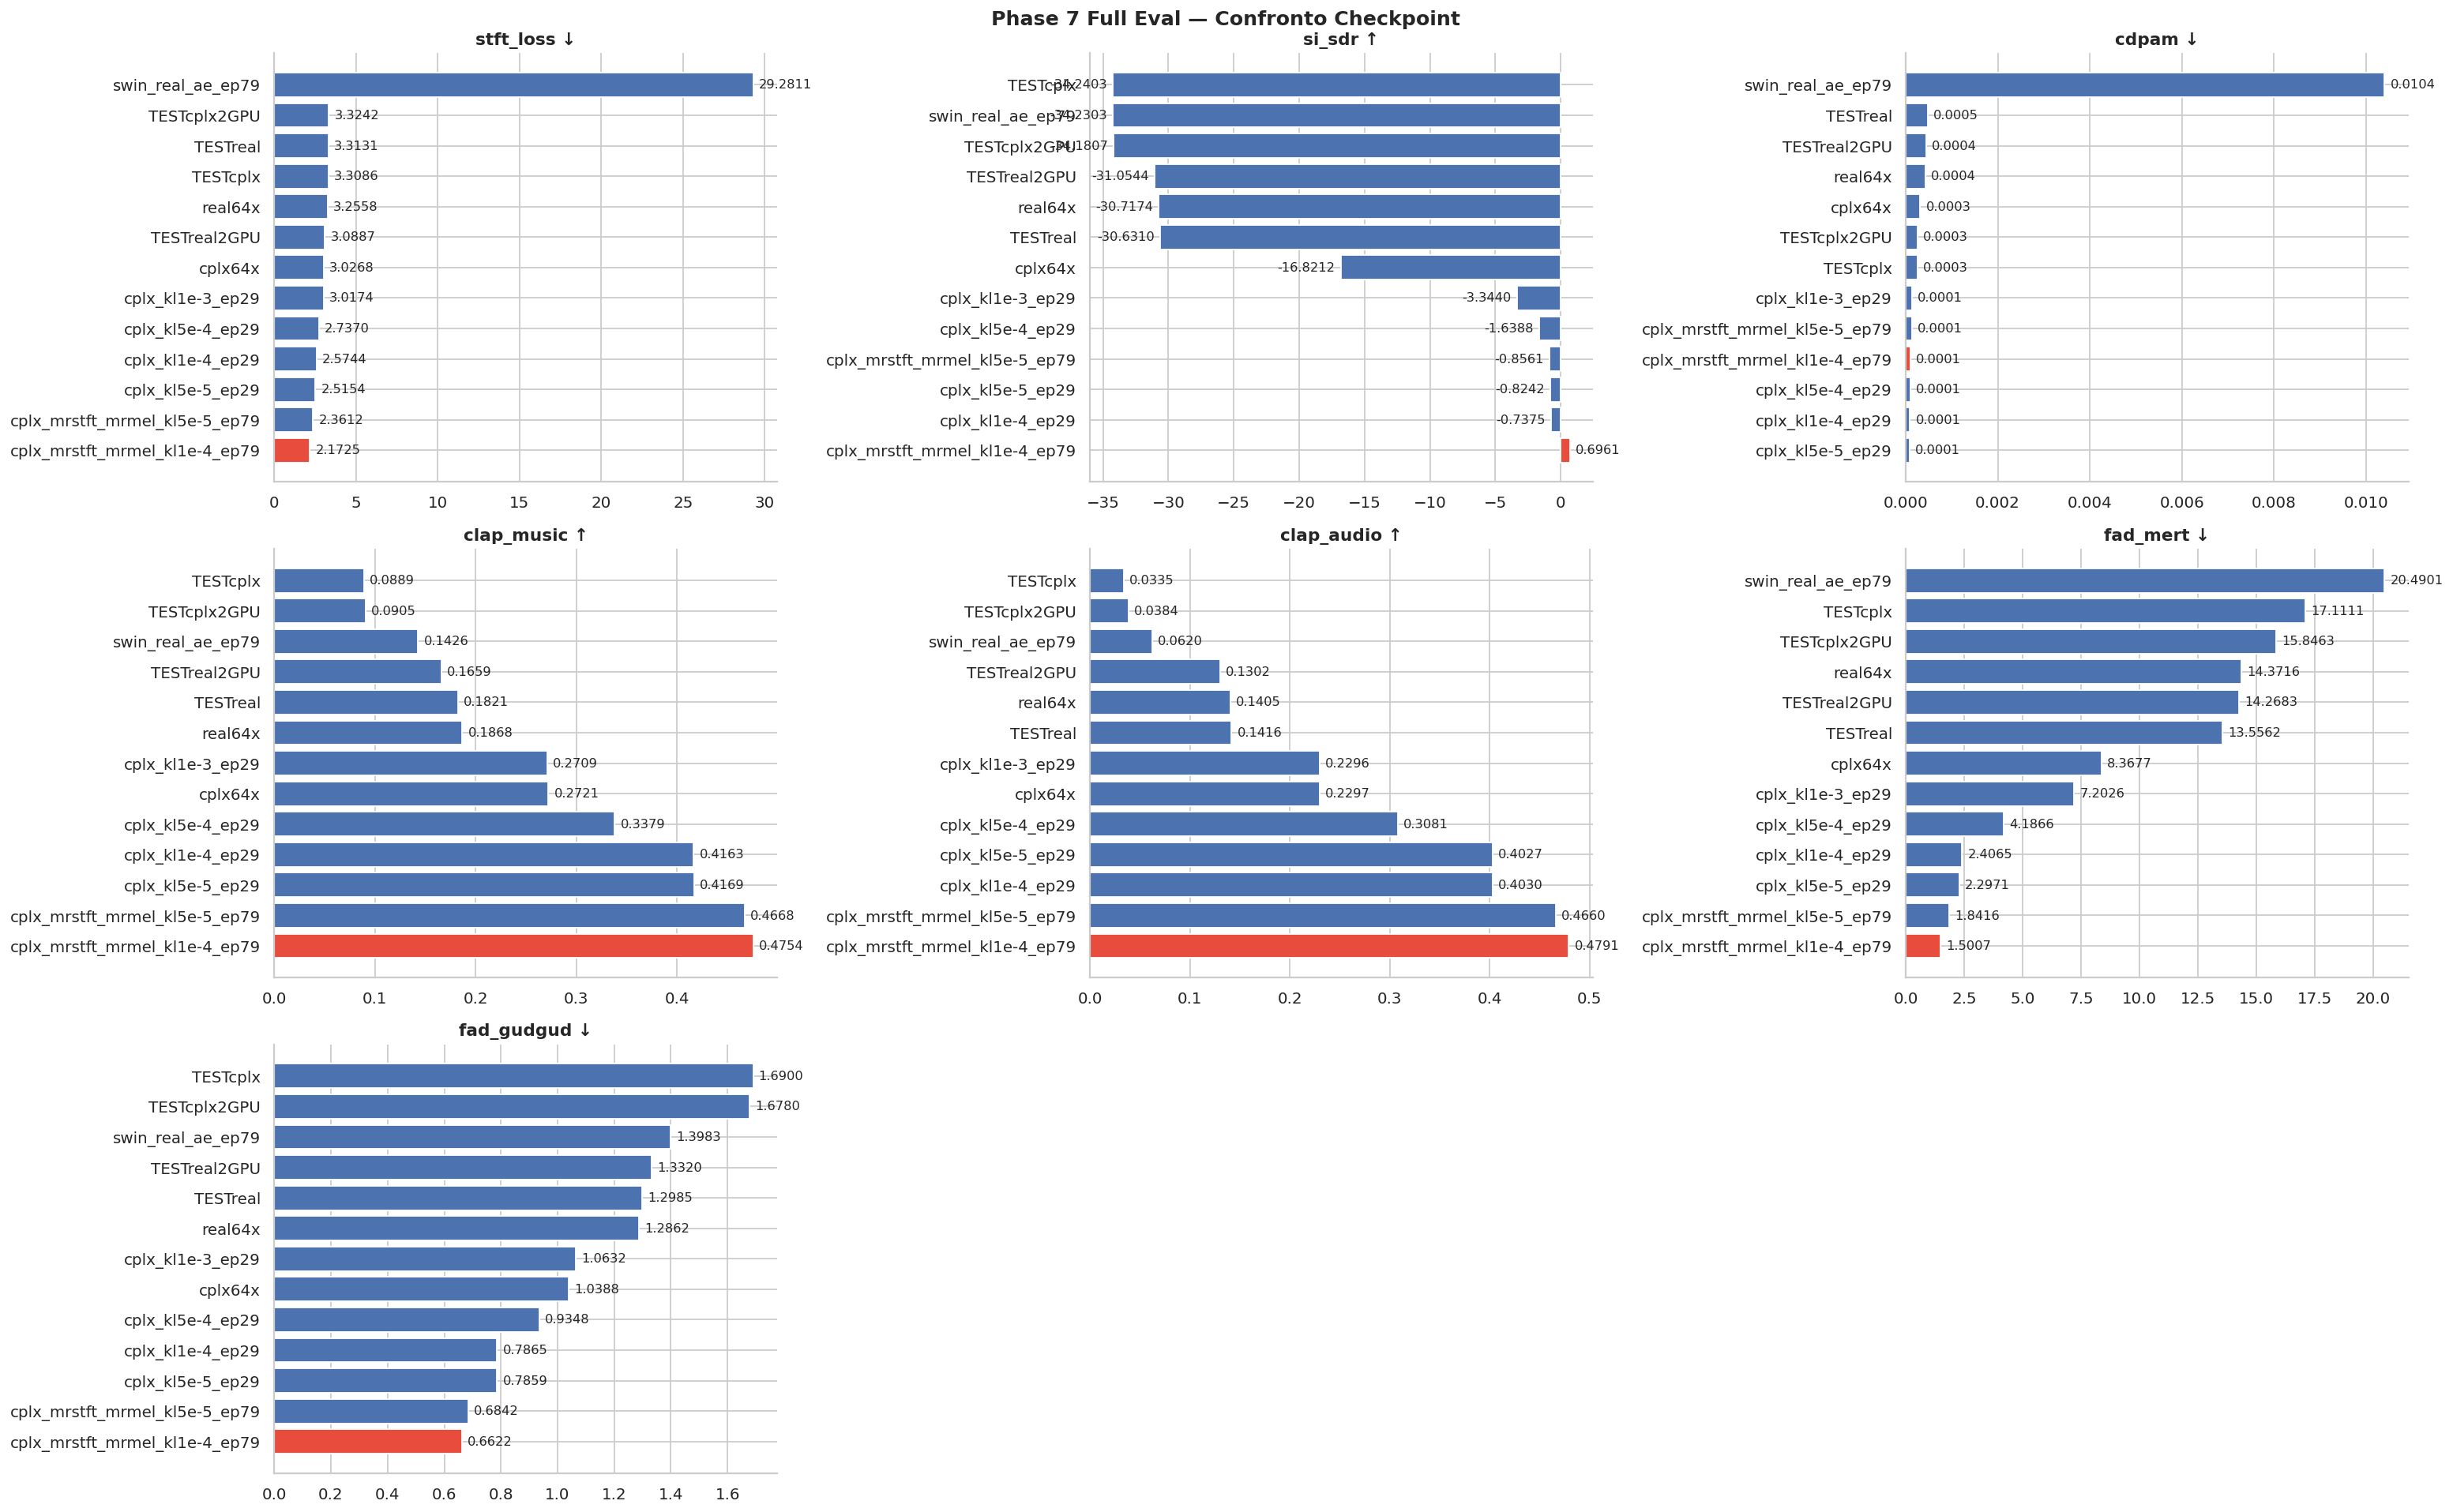

In [26]:
plot_metrics = [c for c in num_cols if df_eval[c].notna().any()]
n = len(plot_metrics)
if n == 0:
    print('Nessuna metrica da plottare.')
else:
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for ax, col in zip(axes, plot_metrics):
        lower_better = METRIC_FMT.get(col, (None, True))[1]
        sub = df_eval[['checkpoint', col]].dropna().sort_values(col, ascending=lower_better)
        colors = ['#E74C3C' if 'BEST' in str(df_eval.loc[df_eval['checkpoint']==r, 'arch_label'].values[0] if not df_eval[df_eval['checkpoint']==r].empty else '') else '#4C72B0' for r in sub['checkpoint']]
        bars = ax.barh(sub['checkpoint'], sub[col], color=colors, edgecolor='white')
        ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
        direction = '↓' if lower_better else '↑'
        ax.set_title(f'{col} {direction}', fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Phase 7 Full Eval — Confronto Checkpoint', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/phase7_eval_bars.png', bbox_inches='tight')
    plt.show()